---
title: |
  Transformers for Sequence Data
subtitle: |
  Specialized neural network modules for processing data sequences. 
jupyter: python3
---

{{< include ../assets/includes/_colab-link.qmd >}}

::: {.content-hidden}

## Boilerplate preamble for LaTeX macros and Python viz style
$$
{{< include ../assets/includes/_macros.tex >}}
$$

In [1]:
import style

:::


[Much of the code for this lecture is based on [this tutorial](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch) by Arjun Sarkar for DataCamp.]{.aside} 

In [2]:
import torch 
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from torch import nn

!pip install torchinfo
from torchinfo import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#| echo: false
# MPS acceleration for Phil to build these notes on his mac
# device = torch.device("mps" if torch.backends.mps.is_available() else device)

## Sequence Data

## The Attention Mechanism

The use of the attention mechanism for natural language processing took off with with a seminal paper by @vaswani2017attention, which integrated the attention mechanism into a neural network architecture called the *transformer*. 

The attention mechanism is a technical expression of a simple idea: 


::: {#fig-attention-diagrams}

![](fig/attention-heads.png)


Schematic diagrams of two attention heads performing different functions. The first attention on the left picks up referential relationships between words, while the one on the right has been trained to detect rhyming words. 

:::

### Dr. Seuss Example

In [4]:
import urllib
url = "https://raw.githubusercontent.com/PhilChodrow/ml-notes-update/refs/heads/main/data/seuss.txt"
text = "\n".join([line.decode('utf-8').strip() for line in urllib.request.urlopen(url)])
print(text[0:193])

The Cat in the Hat

By Dr. Seuss

The sun did not shine.
It was too wet to play.
So we sat in the house
All that cold, cold, wet day.

I sat there with Sally.
We sat there, we two.
And I said, 


Dataset code from previous lecture notes. 

In [5]:
class TextDataSet(Dataset):
    def __init__(self, text, tokenizer = Tokenizer(BPE()), trainer = BpeTrainer(min_frequency=10), context_length = 5): 
        self.context_length = context_length
        self.text = text
        self.tokenizer = tokenizer
        self.tokenizer.train_from_iterator([text], trainer)
        self.tokens = self.tokenizer.encode(text).ids
        self.vocab_length = self.tokenizer.get_vocab_size()

    def __len__(self):
        return len(self.tokens) - self.context_length#<1>
    
    def __getitem__(self, key):
        target = torch.tensor(self.tokens[self.context_length + key])#<2>
        features = self.tokens[key:(self.context_length + key)]#<3>

        feature_tensor = torch.tensor(features, dtype=torch.long)
        feature_text = self.tokenizer.decode(features)#<4>
        target_text = self.tokenizer.decode([target])

        return feature_tensor.to(device), target.to(device), feature_text, target_text


In [131]:
context_length = 10

tokenizer = Tokenizer(BPE(), )
trainer   = BpeTrainer(min_frequency=100)
tokenizer.add_tokens(['\n'])
tokenizer.train_from_iterator([text], trainer, )

data = TextDataSet(
    text, 
    tokenizer = tokenizer, 
    trainer = trainer, 
    context_length = context_length
    )
print(f"Number of training examples: {len(data)}")
print(f"Vocabulary size: {data.vocab_length}")







Number of training examples: 25130
Vocabulary size: 114


In [132]:
loader = DataLoader(data, batch_size = 32, shuffle = True)
X_batch, y_batch, X_text, y_text = next(iter(loader))
print("Batch of features (token ids):", X_batch)
print("Batch of targets (token ids):", y_batch)
print("Batch of features (text):", X_text)
print("Batch of targets (text):", y_text)

Batch of features (token ids): tensor([[ 77,  47,  81,  66,  44,  78,  63,  58,   0,   0],
        [112,  92,  99,   4,  78,  87,  57,  48,  66,   1],
        [ 51,  74, 103,  54,  48,  78, 105,  47,  61,  80],
        [ 64,  55,   1,  52,  47,  48,  44,   2,   0,  37],
        [ 48,  50,  50,  78, 108,  51,  44,  56,   2,   0],
        [ 95,  93,  63,  82,  98,  95,  93,  63,  82,  98],
        [ 47,   9,   1,  37,  51,  97,  97,  93,  76,  61],
        [ 56,   0,  36,  44,  56,   1,  91,  44,  56,   0],
        [ 51,  44,  65,  74,  45,  48,  48,  89,  75,  94],
        [ 88,  50,  48,  76,  62,  58,  99,   0, 108,  96],
        [ 66,  82,  51,  83,  50, 100,   1,  87,  56,  52],
        [  0,  26,   4,  56,   1,  62,  81,  62,  58,  61],
        [ 52,  77,  85,  20,  94, 106,  85,  25,  44,  63],
        [ 87,  59,  58,  63,   2,   0,  25,  74,  62,  44],
        [ 47,  47,  55,  48,  78, 106,  87,  59,  64,  47],
        [ 97,  57,  48,  66,  17,   0,  25, 107,   1, 104],
        [

In [133]:
X_batch.dtype

torch.int64

### Key-Query-Value (KQV) Attention

[The mathematical exposition of the KQV attention mechanism is based on Chapter 12.1 of @bishop2023deep.]{.aside}

In [134]:
class AttentionHead(torch.nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.W_q = torch.nn.Linear(d_model, d_k)
        self.W_k = torch.nn.Linear(d_model, d_k)
        self.W_v = torch.nn.Linear(d_model, d_k)

    def forward(self, x):
        Q = self.W_q(x)  # Queries
        K = self.W_k(x)  # Keys
        V = self.W_v(x)  # Values

        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)
        attention_weights = torch.nn.functional.softmax(scores, dim=-1)

        # Compute the output as a weighted sum of values
        output = torch.matmul(attention_weights, V)
        return output

In [135]:
class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(1), :]
        return x

In [136]:
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, d_k, num_heads, d_output):
        super().__init__()
        self.heads = torch.nn.ModuleList([AttentionHead(d_model, d_k) for _ in range(num_heads)])
        self.linear = torch.nn.Linear(num_heads * d_k, d_output)

    def forward(self, x):
        head_outputs = [head(x) for head in self.heads]
        concatenated = torch.cat(head_outputs, dim=-1)
        output = self.linear(concatenated)
        return output

In [137]:
class AttentionModel(torch.nn.Module):
    def __init__(self, vocab_size, d_model, d_k, num_heads, context_length, hidden_dim, d_output):
        super().__init__()
        self.embedding = torch.nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model)
        self.multi_head_attention = MultiHeadAttention(d_model, d_k, num_heads, d_output)
        self.fc = torch.nn.Linear(d_output*context_length, vocab_size)  # Fully connected layer to output vocab size
        # self.output_layer = torch.nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.positional_encoding(x)
        x = self.multi_head_attention(x)
        
        x = torch.flatten(x, start_dim=1)  # Flatten the output for the fully connected layer   
        
        x = self.fc(nn.functional.relu(x))
        # output = self.output_layer(nn.functional.relu(x))
        return x

In [146]:
model = AttentionModel(vocab_size=data.vocab_length, d_model=4, d_k=4, num_heads=8, context_length=context_length, hidden_dim = 256, d_output=8).to(device)

summary(model, input_size=(32, context_length), device = device, dtypes = [torch.long])


Layer (type:depth-idx)                   Output Shape              Param #
AttentionModel                           [32, 114]                 --
├─Embedding: 1-1                         [32, 10, 4]               456
├─PositionalEncoding: 1-2                [32, 10, 4]               --
├─MultiHeadAttention: 1-3                [32, 10, 8]               --
│    └─ModuleList: 2-1                   --                        --
│    │    └─AttentionHead: 3-1           [32, 10, 4]               60
│    │    └─AttentionHead: 3-2           [32, 10, 4]               60
│    │    └─AttentionHead: 3-3           [32, 10, 4]               60
│    │    └─AttentionHead: 3-4           [32, 10, 4]               60
│    │    └─AttentionHead: 3-5           [32, 10, 4]               60
│    │    └─AttentionHead: 3-6           [32, 10, 4]               60
│    │    └─AttentionHead: 3-7           [32, 10, 4]               60
│    │    └─AttentionHead: 3-8           [32, 10, 4]               60
│    └─Linear:

In [153]:
n_epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()
for epoch in range(n_epochs):
    loss_total = 0
    for X_batch, y_batch, _, _ in loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss_total/len(loader):.4f}")

Epoch 1/20, Loss: 3.2311
Epoch 2/20, Loss: 3.1939
Epoch 3/20, Loss: 3.1787
Epoch 4/20, Loss: 3.1644
Epoch 5/20, Loss: 3.1520
Epoch 6/20, Loss: 3.1465
Epoch 7/20, Loss: 3.1397
Epoch 8/20, Loss: 3.1332


KeyboardInterrupt: 

In [148]:
def boltzmann_prediction(preds, temperature = 1.0):
    probabilities = torch.nn.Softmax(dim = None)(preds / temperature)
    return torch.multinomial(probabilities, num_samples=1).item()

def format_line(line): 
    if line.isupper():
        return "\n" + line + ":"
    else:
        return line

def format_text(text): 
    text = text.replace("  ", "<SPACE>").replace(" ", "").replace("<SPACE>", " ")
    return "\n".join([format_line(line) for line in text.split("\n")])

def generate(model, data, init_tokens, context_length = 5, n_tokens = 200, temperature = 1.0):
    
    generated_tokens = init_tokens #<1>
    context = generated_tokens[-context_length:]

    for _ in range(n_tokens):
        model_input = context.unsqueeze(0)
        scores = model.forward(model_input) #<2>
        y_pred = boltzmann_prediction(scores, temperature = temperature) #<3>
        generated_tokens = torch.cat((generated_tokens, torch.tensor([y_pred], dtype=torch.long))) #<4>
        context = generated_tokens[-context_length:] #<5>
    decoded = data.tokenizer.decode( #<6>
        generated_tokens.tolist(), 
        skip_special_tokens = True
        )
    
    return format_text(decoded)

In [154]:
generated_text = generate(model, data, init_tokens = torch.tensor(data.tokens[0:context_length], dtype=torch.long).to(device), context_length = context_length, n_tokens = 200, temperature = .5)
print(generated_text)

/Users/philchodrow/opt/anaconda3/envs/cs451/lib/python3.10/site-packages/torch/nn/modules/module.py:1776: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


The Cat in the Hat.

And oun anik a dix se.

I mek seit gles a may.

And hen  a look 
a lir se He ghing. I fould not 
our minge.

Be and heas bax.
""hen se eo wat he bew sane set.

I do not like them a ran

hen not gad.

Brad hee be dras to bo sated bowut.
In ome mee mow.

WHe se wags Wrick oi


In [155]:
# test_sequence = "I do not like them with a fox" # works for context length 5
# test_sequence = "I do not like green eggs and" 
# test_tokens = data.tokenizer.encode(test_sequence).ids

# 202
input_tokens, _, input_text, _ = data[550]

print("Test text:", input_text)
print("Test tokens:", input_tokens)

Test text: w   s om e  n e w   t
Test tokens: tensor([ 66,   1,  62, 111,  74,  57,  48,  66,   1,  63])


In [156]:
outputs = model.forward(torch.tensor(input_tokens[-context_length:], dtype=torch.long).unsqueeze(0).to(device))

next_token = boltzmann_prediction(outputs, temperature = 1)
print("Predicted next token id:", next_token)
print("Predicted next token text:", data.tokenizer.decode([next_token]))

Predicted next token id: 89
Predicted next token text: n 


/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_53815/2591844492.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputs = model.forward(torch.tensor(input_tokens[-context_length:], dtype=torch.long).unsqueeze(0).to(device))


/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_53815/2573672332.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = model.embedding(torch.tensor(input_tokens[-context_length:], dtype=torch.long).unsqueeze(0).to(device))


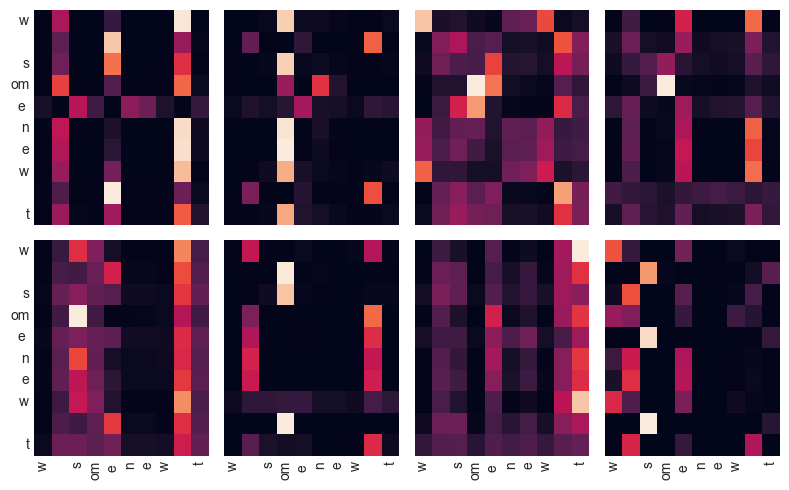

In [157]:
# inspect the attention weights for the first head of the multi-head attention layer
from matplotlib import pyplot as plt 
import seaborn as sns
fig, ax = plt.subplots(2, 4, figsize=(8, 5))

with torch.no_grad():
    x = model.embedding(torch.tensor(input_tokens[-context_length:], dtype=torch.long).unsqueeze(0).to(device))
    x = model.positional_encoding(x)
    head_outputs = [head(x) for head in model.multi_head_attention.heads]
    attention_weights = [torch.nn.functional.softmax(torch.matmul(head.W_q(x), head.W_k(x).transpose(-2, -1)) / (head.W_k(x).size(-1) ** 0.5), dim=-1) for head in model.multi_head_attention.heads]
    
# # Plot the attention weights for the first head

ticks = [tokenizer.decode([token]) for token in input_tokens]


for k, weights in enumerate(attention_weights):
    i, j = k // 4, k % 4
    
    sns.heatmap(weights.squeeze().cpu().numpy(), ax=ax[i, j], cbar = False)
    # ax[i, j].set_title(f'Head {k+1}')
    if i == 1:
        ax[i, j].set_xticks(torch.arange(context_length)+0.5)
        ax[i, j].set_xticklabels(ticks, rotation=90)
    else:
        ax[i, j].set_xticks([])
    
    if j == 0:
        ax[i, j].set_yticks(torch.arange(context_length)+0.5)
        ax[i, j].set_yticklabels(ticks, rotation=0)
    else: 
        ax[i, j].set_yticks([])


plt.tight_layout()


### Self-Attention

## A First Attention-Based Model

## Towards Transformers

## References
